# Como o Python Funciona Internamente

https://medium.com/@rajrohan88293/under-the-hood-demystifying-pythons-internal-workings-4b2b17707516  
https://bytemedirk.medium.com/how-the-python-programming-language-works-f2db6e421f87  
https://dev.to/vayolapradeep/how-python-programs-works-15f    
https://dev.to/yaswanthteja/internals-of-python-11ed

Python é uma linguagem de programação `interpretada` *(Uma linguagem de programação interpretada é uma linguagem na qual o código-fonte (o que você escreve) é executado linha por linha por um programa chamado interpretador, sem a necessidade de uma etapa de compilação prévia para gerar um código executável em linguagem de máquina.)* de alto nível *(fácil de entender e escrever por seres humanos)*. Ela deseja que você resolva problemas ao invés de se preocupar com memória ou operações do sistema.

1. Fazemos o código fonte:
```python
def foobar(name: str) -> str:
    return f'Hi {name}'

print(foobar(name='Egito'))
```

2. Compilador:

Converte o código python em `bytecode` *(`bytecode` é uma representação intermediaria de baixo nivel do seu programa, é um conjunto de instruções que a Mquina Virtual do Pthon PVM consegue interpretar)*
   1. **Análise Léxica**: O código-fonte é divido em `tokens` (PALAVRAS-CHAVE, IDENTIFICADORES, OPERADORES, etc.).
   2. **Análise sintática**: Esses `tokens` são usados para construir uma `árvore de sintaxe abstrata (AST)`, que representa a estrutura do código.
   3. **Compilação**: A AST é então compilada em bytecode.

Esse `bytecode` é armazenado em `.pyc` arquivos (no `__pycache__`) para reutilização, evitando a necessidade de recompilar o código a cada vez.

In [1]:
import dis

def foobar(name: str) -> str:
    return f'Hi {name}'

dis.dis(foobar)

  3           0 RESUME                   0

  4           2 LOAD_CONST               1 ('Hi ')
              4 LOAD_FAST                0 (name)
              6 FORMAT_VALUE             0
              8 BUILD_STRING             2
             10 RETURN_VALUE


Esse `bytecode` não é código de maquina ainda, mas uma representação intermediária independente de plataforma.

3. Interpretador: Executa o `bytecode` usando a `PVM`

A `PVM` lê cada instrução do `bytecode` um de cada vez, e executa as operações correspondentes. A natureza desacoplada do Python:

- Compilador e interpretador em conjunto: Python separa o processo de compilação (código-fonte → bytecode) da interpretação (bytecode → execução), isso permite flexibilidade.
    - O mesmo `bytecode` pode ser reutilizado em diferentes plataformas (com PVMs especificos para cada plataforma)
    - Os desenvolvedores podem modificar o interpretador (por exemplo, substituir o `CPython` pelo `PyPy`) sem afetar o funcionamento do compilador.

4. Armazenamento em cache
- O Python armazena automaticamente em cache o `bytecode` compilaod em `.pyc` que vai para a pasta `__pycache__` sendo assim na próxima execução esse arquivo é utilizado e não precisamos refazer todo o processo.

5. Flexibilidade
- A arquitetura do Python permite que os desenvolvedores troquem o interpretador (CPython, Jython, PyPy) sem precisar reescrever o código.
  1. `CPython`: O interpretador padrão do Python escrito em `C`
  2. `Jython`: Permite que o código Python seja executado na JVM (Java Virtual Machine)
  3. `PyPy`: Compilador Just-In-Time (JIT) para Python, que oferece melhorias de velocidade
  4. `IronPython`: Integra o Python com o framework .NET

6. `bytecode`

O `bytecode` é uma abstração projetada para portabilidade, enquanto o código de maquina interage diretamente com o hardware, no python `bytecode` ≠ `código de maquina`.

7. `PVM`

Máquina virtual baseada em pilha, responsável por interpretar e executar o bytecode do Python.
  1. Implementado em `C` (no caso do `CPython`)
  2. A PVM lê e executa instruções de bytecode geradas pelo compilador Python.
  3. Diferentemente do hardware físico, a PVM é um mecanismo de execução baseado em software , que fornece uma camada de abstração para programas Python.

Cada operação de bytecode corresponde a uma função manipuladora escrita em C dentro do núcleo do CPython. Esse design permite que a PVM execute código Python de forma eficiente.
```python
result = (3 + 5) * 2

0 LOAD_CONST               1 (3)
2 LOAD_CONST               2 (5)
4 BINARY_ADD
6 LOAD_CONST               3 (2)
8 BINARY_MULTIPLY
10 STORE_NAME              0 (result)
```
- LOAD_CONST (3): Push 3 onto the stack.
- LOAD_CONST (5): Push 5 onto the stack.
- BINARY_ADD: Pop 3 and 5, add them, and push the result (8) onto the stack.
- LOAD_CONST (2): Push 2 onto the stack.
- BINARY_MULTIPLY: Pop 8 and 2, multiply them, and push the result (16) onto the stack.
- STORE_NAME: Assign the result (16) to the variable result.

Em CPython, a PVM é implementada como um loop que busca, decodifica e executa instruções de bytecode.
```c
while (1) {
    instruction = fetch_next_bytecode();  // Fetch the next instruction
    execute_instruction(instruction);    // Map to the appropriate C function
}
```

8. Sistema de memória

O Python possui um sistema de gerenciamento de memória altamente otimizado e automatizado. Ele inclui três componentes principais:
- **Contagem de Referência:** O principal mecanismo para rastrear e gerenciar a memória.
- **Coleta de Lixo:** Um sistema complementar para a limpeza de referências circulares.
- **Alocador de memória:** um sistema que otimiza a alocação de memória e reutiliza blocos de memória para melhorar o desempenho.
```python
# Criando um objeto
 a = [1, 2, 3]   # A contagem de referências para a lista agora é 1
 b = a           # A contagem de referências aumenta para 2
 del a           # A contagem de referências diminui para 1
 del b           # A contagem de referências diminui para 0 (o objeto é desalocado)
```

In [3]:
import gc

In [4]:
# Habilitar saída de depuração 
gc.set_debug(gc.DEBUG_LEAK)
# Criar referências circulares 
a = [] 
b = [a] 
a.append(b)
# Remover referências 
del a 
del b
# Forçar a coleta de lixo 
gc.collect()

gc: collectable <MagicHelpFormatter 0x00000200C059FF50>
gc: collectable <_Section 0x00000200C059FF20>
gc: collectable <list 0x00000200C05C0D00>
gc: collectable <tuple 0x00000200C05C4450>
gc: collectable <method 0x00000200C05C3000>
gc: collectable <tuple 0x00000200C05A8B80>
gc: collectable <tuple 0x00000200C05A8500>
gc: collectable <tuple 0x00000200C05A8780>
gc: collectable <tuple 0x00000200C05A8680>
gc: collectable <list 0x00000200C05C3500>
gc: collectable <method 0x00000200C05C3540>
gc: collectable <list 0x00000200C05C3600>
gc: collectable <method 0x00000200C05C35C0>
gc: collectable <list 0x00000200C05C37C0>
gc: collectable <method 0x00000200C05C3640>
gc: collectable <_Section 0x00000200C05D82F0>
gc: collectable <_Section 0x00000200C05D82C0>
gc: collectable <list 0x00000200C05C3580>
gc: collectable <list 0x00000200C05C3680>
gc: collectable <tuple 0x00000200C05A8540>
gc: collectable <tuple 0x00000200C05A8800>
gc: collectable <tuple 0x00000200C05A8700>
gc: collectable <tuple 0x00000200C

39

In [6]:
import sys

In [7]:
# Uso de memória dos objetos 
x = [] 
print(sys.getsizeof(x)) # Memória alocada para uma lista vazia
x.append(1) 
print(sys.getsizeof(x)) # Memória alocada após adicionar um elemento

56
88


Em suma Python é `compilado` e o resultado dessa compilação é `interpretado`.

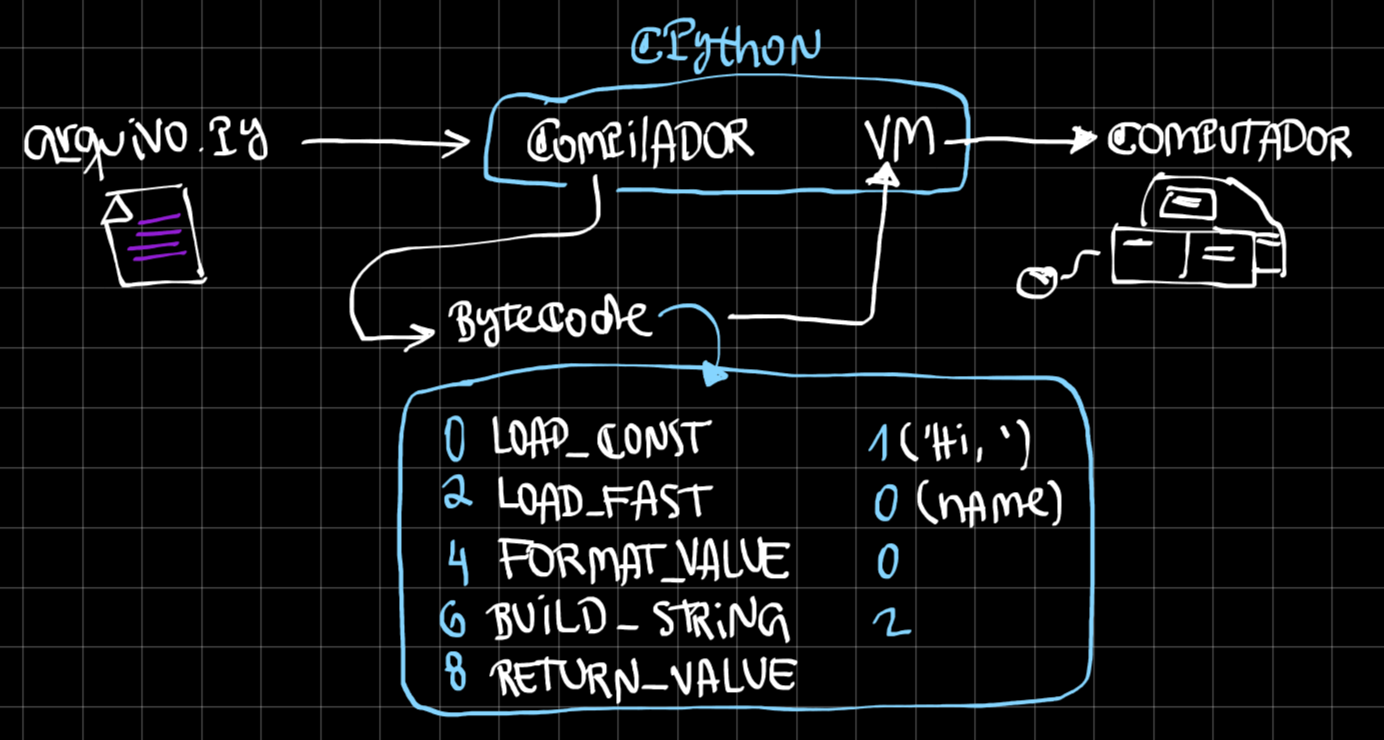